In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mingangolo/player-comparision/database.sqlite


In [2]:
import pandas as pd
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

conn = sqlite3.connect('/kaggle/input/datasets/mingangolo/player-comparision/database.sqlite')

players = pd.read_sql("SELECT * FROM Player", conn)
player_attrs = pd.read_sql("SELECT * FROM Player_Attributes", conn)

# Clean
player_attrs = player_attrs.dropna(subset=['overall_rating'])
num_cols = player_attrs.select_dtypes(include='number').columns
player_attrs[num_cols] = player_attrs[num_cols].fillna(player_attrs[num_cols].median())

# Get latest attributes per player
latest = player_attrs.sort_values('date').groupby('player_api_id').last().reset_index()
latest = latest.merge(players, on='player_api_id')

print(f"Ready! {len(latest)} players available for comparison")

Ready! 11060 players available for comparison


In [3]:
def compare_players(player1_name, player2_name):
    # Attributes to compare
    attrs = [
        'finishing', 'dribbling', 'short_passing', 
        'long_passing', 'ball_control', 'acceleration',
        'sprint_speed', 'stamina', 'strength', 
        'reactions', 'vision', 'positioning'
    ]
    
    # Find players
    p1 = latest[latest['player_name'].str.contains(player1_name, case=False)]
    p2 = latest[latest['player_name'].str.contains(player2_name, case=False)]
    
    if p1.empty:
        print(f"Player '{player1_name}' not found!")
        return
    if p2.empty:
        print(f"Player '{player2_name}' not found!")
        return
    
    p1 = p1.iloc[0]
    p2 = p2.iloc[0]
    
    # Get values
    p1_vals = [p1[attr] for attr in attrs]
    p2_vals = [p2[attr] for attr in attrs]
    
    # Radar chart setup
    N = len(attrs)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    p1_vals += p1_vals[:1]
    p2_vals += p2_vals[:1]
    
    # Plot
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    ax.plot(angles, p1_vals, 'o-', linewidth=2, color='#e74c3c', label=p1['player_name'])
    ax.fill(angles, p1_vals, alpha=0.2, color='#e74c3c')
    
    ax.plot(angles, p2_vals, 'o-', linewidth=2, color='#3498db', label=p2['player_name'])
    ax.fill(angles, p2_vals, alpha=0.2, color='#3498db')
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(attrs, size=10)
    ax.set_ylim(0, 100)
    
    plt.title(f'{p1["player_name"]} vs {p2["player_name"]}\n'
              f'Overall: {p1["overall_rating"]:.0f} vs {p2["overall_rating"]:.0f}', 
              size=14, pad=20)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    
    plt.tight_layout()
    plt.savefig('player_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print stat comparison
    print(f"\n{'Attribute':<20} {p1['player_name']:<25} {p2['player_name']:<25} {'Winner':<10}")
    print("=" * 85)
    for attr, v1, v2 in zip(attrs, p1_vals[:-1], p2_vals[:-1]):
        winner = p1['player_name'] if v1 > v2 else (p2['player_name'] if v2 > v1 else 'Draw')
        print(f"{attr:<20} {v1:<25.0f} {v2:<25.0f} {winner:<10}")

print("Function ready!")

Function ready!


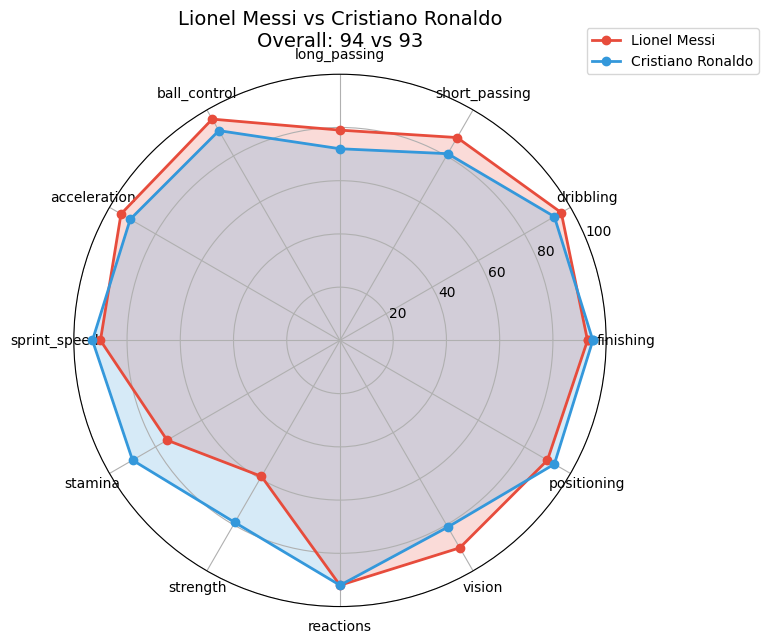


Attribute            Lionel Messi              Cristiano Ronaldo         Winner    
finishing            93                        95                        Cristiano Ronaldo
dribbling            96                        93                        Lionel Messi
short_passing        88                        81                        Lionel Messi
long_passing         79                        72                        Lionel Messi
ball_control         96                        91                        Lionel Messi
acceleration         95                        91                        Lionel Messi
sprint_speed         90                        93                        Cristiano Ronaldo
stamina              75                        90                        Cristiano Ronaldo
strength             59                        79                        Cristiano Ronaldo
reactions            92                        92                        Draw      
vision               90              

In [4]:
compare_players('Messi', 'Ronaldo')

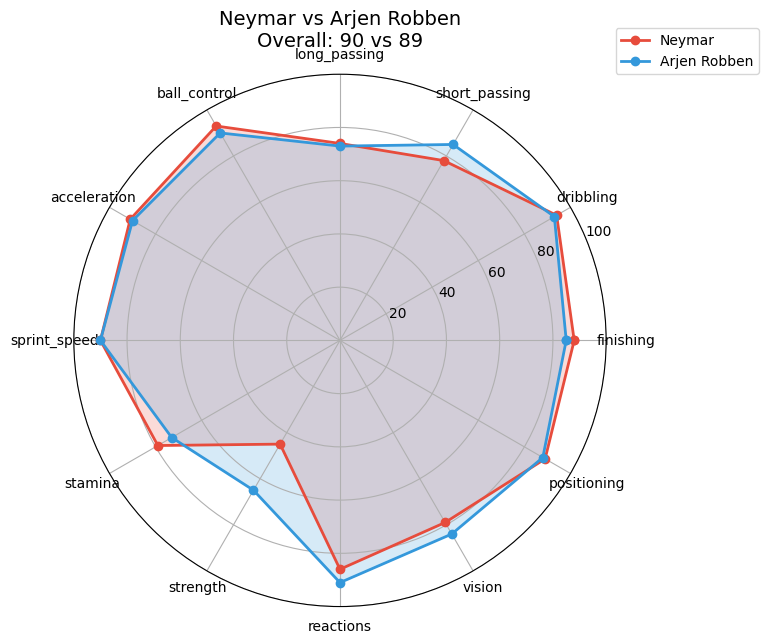


Attribute            Neymar                    Arjen Robben              Winner    
finishing            88                        85                        Neymar    
dribbling            94                        93                        Neymar    
short_passing        78                        85                        Arjen Robben
long_passing         74                        73                        Neymar    
ball_control         93                        90                        Neymar    
acceleration         91                        90                        Neymar    
sprint_speed         90                        90                        Draw      
stamina              79                        73                        Neymar    
strength             45                        65                        Arjen Robben
reactions            86                        91                        Arjen Robben
vision               79                        84                    

In [5]:
compare_players('Neymar', 'Robben')

In [6]:
def compare_players_summary(player1_name, player2_name):
    attrs = [
        'finishing', 'dribbling', 'short_passing',
        'long_passing', 'ball_control', 'acceleration',
        'sprint_speed', 'stamina', 'strength',
        'reactions', 'vision', 'positioning'
    ]

    p1 = latest[latest['player_name'].str.contains(player1_name, case=False)]
    p2 = latest[latest['player_name'].str.contains(player2_name, case=False)]

    if p1.empty or p2.empty:
        print("One or both players not found!")
        return

    p1 = p1.iloc[0]
    p2 = p2.iloc[0]

    p1_wins = 0
    p2_wins = 0
    draws = 0

    for attr in attrs:
        if p1[attr] > p2[attr]:
            p1_wins += 1
        elif p2[attr] > p1[attr]:
            p2_wins += 1
        else:
            draws += 1

    print(f"\n{'='*40}")
    print(f"OVERALL VERDICT")
    print(f"{'='*40}")
    print(f"{p1['player_name']:<25} {p1_wins} wins")
    print(f"{p2['player_name']:<25} {p2_wins} wins")
    print(f"Draws:                    {draws}")
    print(f"{'='*40}")

    if p1_wins > p2_wins:
        print(f"🏆 {p1['player_name']} wins overall!")
    elif p2_wins > p1_wins:
        print(f"🏆 {p2['player_name']} wins overall!")
    else:
        print("🤝 It's a draw!")

    print(f"\nOverall ratings:")
    print(f"{p1['player_name']}: {p1['overall_rating']:.0f}")
    print(f"{p2['player_name']}: {p2['overall_rating']:.0f}")

# Test it
compare_players_summary('Messi', 'Ronaldo')


OVERALL VERDICT
Lionel Messi              6 wins
Cristiano Ronaldo         5 wins
Draws:                    1
🏆 Lionel Messi wins overall!

Overall ratings:
Lionel Messi: 94
Cristiano Ronaldo: 93


In [7]:
# Save comparison data for all players
comparison_data = latest[[
    'player_name', 'overall_rating', 'finishing', 'dribbling',
    'short_passing', 'long_passing', 'ball_control', 'acceleration',
    'sprint_speed', 'stamina', 'strength', 'reactions', 
    'vision', 'positioning'
]].copy()

comparison_data.to_csv('player_comparison_data.csv', index=False)
print("Saved!")
print(f"Total players available for comparison: {len(comparison_data)}")

Saved!
Total players available for comparison: 11060
